# Lab 9.6.2

In [1]:
set.seed(1)
x=matrix(rnorm (200*2) , ncol=2)
x[1:100,]=x[1:100,]+2
x[101:150 ,]=x[101:150,]-2
y=c(rep(1,150) ,rep(2,50))
dat=data.frame(x=x,y=as.factor(y))

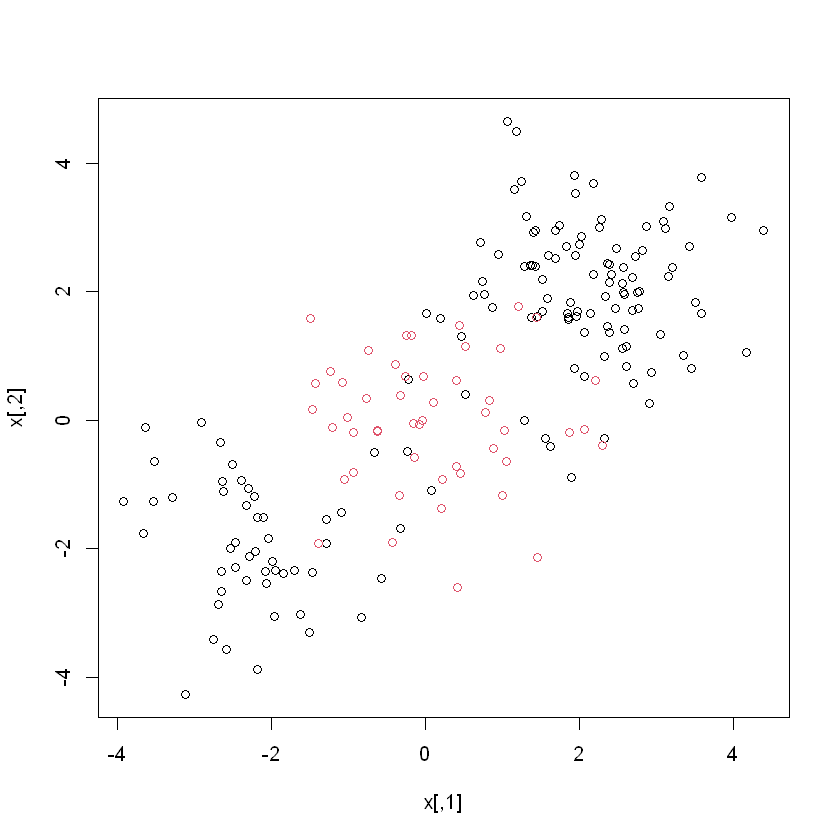

In [2]:
plot(x, col=y)

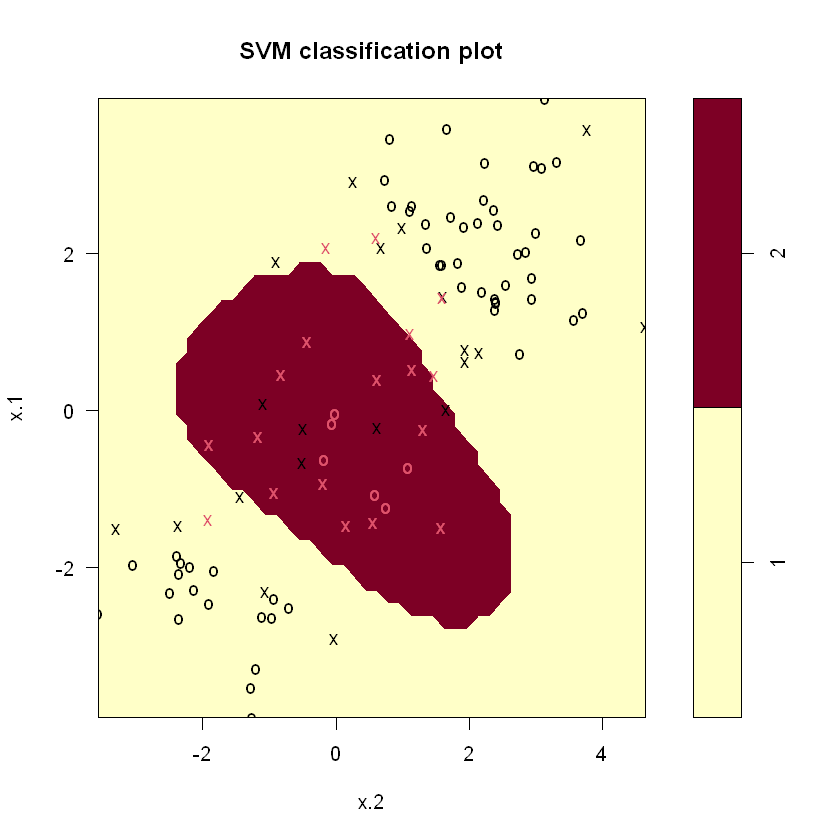

In [14]:
library(e1071)
train=sample (200,100)
svmfit=svm(y~., data=dat[train ,], kernel ="radial", gamma=1,cost=1)
plot(svmfit , dat[train ,])

In [4]:
summary(svmfit)


Call:
svm(formula = y ~ ., data = dat[train, ], kernel = "radial", gamma = 1, 
    cost = 1)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  32

 ( 15 17 )


Number of Classes:  2 

Levels: 
 1 2




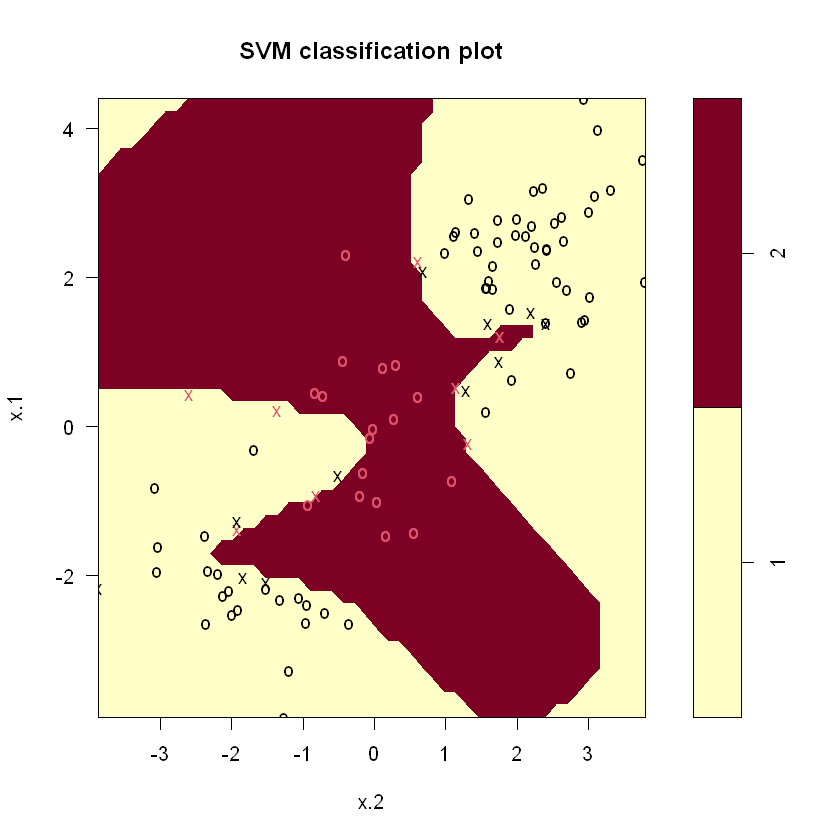

In [5]:
svmfit=svm(y~., data=dat[train ,], kernel ="radial",gamma=1, cost=1e5)
plot(svmfit ,dat[train ,])

In [6]:
set.seed(1)
tune.out=tune(svm , y~., data=dat[train ,], kernel ="radial", ranges=list(cost=c(0.1,1,10,100,1000), gamma=c(0.5,1,2,3,4) ))
summary (tune.out)


Parameter tuning of 'svm':

- sampling method: 10-fold cross validation 

- best parameters:
 cost gamma
   10   0.5

- best performance: 0.07 

- Detailed performance results:
    cost gamma error dispersion
1  1e-01   0.5  0.25 0.11785113
2  1e+00   0.5  0.08 0.09189366
3  1e+01   0.5  0.07 0.08232726
4  1e+02   0.5  0.11 0.11005049
5  1e+03   0.5  0.13 0.13374935
6  1e-01   1.0  0.22 0.14757296
7  1e+00   1.0  0.08 0.10327956
8  1e+01   1.0  0.10 0.09428090
9  1e+02   1.0  0.11 0.07378648
10 1e+03   1.0  0.13 0.08232726
11 1e-01   2.0  0.24 0.14298407
12 1e+00   2.0  0.09 0.09944289
13 1e+01   2.0  0.12 0.11352924
14 1e+02   2.0  0.10 0.06666667
15 1e+03   2.0  0.11 0.07378648
16 1e-01   3.0  0.25 0.11785113
17 1e+00   3.0  0.09 0.09944289
18 1e+01   3.0  0.11 0.08755950
19 1e+02   3.0  0.14 0.06992059
20 1e+03   3.0  0.14 0.09660918
21 1e-01   4.0  0.25 0.11785113
22 1e+00   4.0  0.10 0.09428090
23 1e+01   4.0  0.11 0.08755950
24 1e+02   4.0  0.13 0.08232726
25 1e+03   4.0  0.13 0

In [7]:
table(true=dat[-train ,"y"], pred=predict (tune.out$best.model , newdata =dat[-train ,]))

    pred
true  1  2
   1 65 10
   2  3 22

# Lab 9.6.3

In [12]:
library(ROCR)
rocplot = function (pred , truth , ...){
    predob = prediction (pred , truth)
    perf = performance (predob , "tpr", "fpr")
    plot(perf ,...)}

In [9]:
svmfit.opt=svm(y~., data=dat[train ,], kernel ="radial",gamma=2, cost=1, decision.values =T)
fitted =attributes (predict (svmfit.opt ,dat[ train ,], decision.values=TRUE))$decision.values

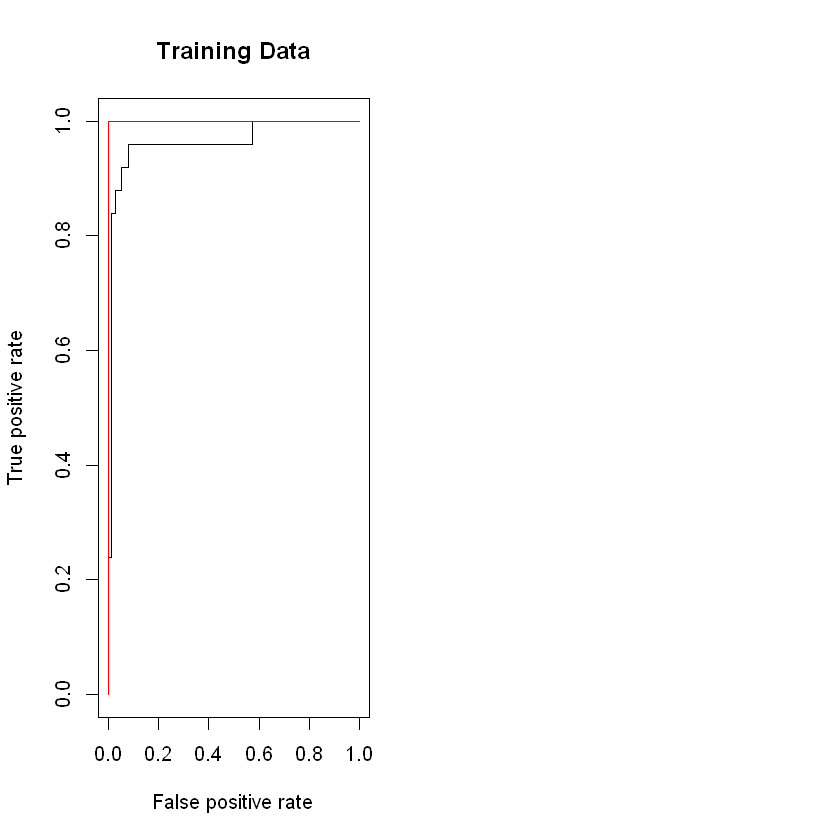

In [10]:
par(mfrow=c(1,2))
rocplot (fitted ,dat[train ,"y"], main="Training Data")
svmfit.flex=svm(y~., data=dat[train ,], kernel ="radial", gamma=50, cost=1, decision.values =T)
fitted=attributes (predict (svmfit.flex ,dat[ train ,], decision.values=T))$decision.values
rocplot(fitted ,dat[train ,"y"],add=T,col="red ")

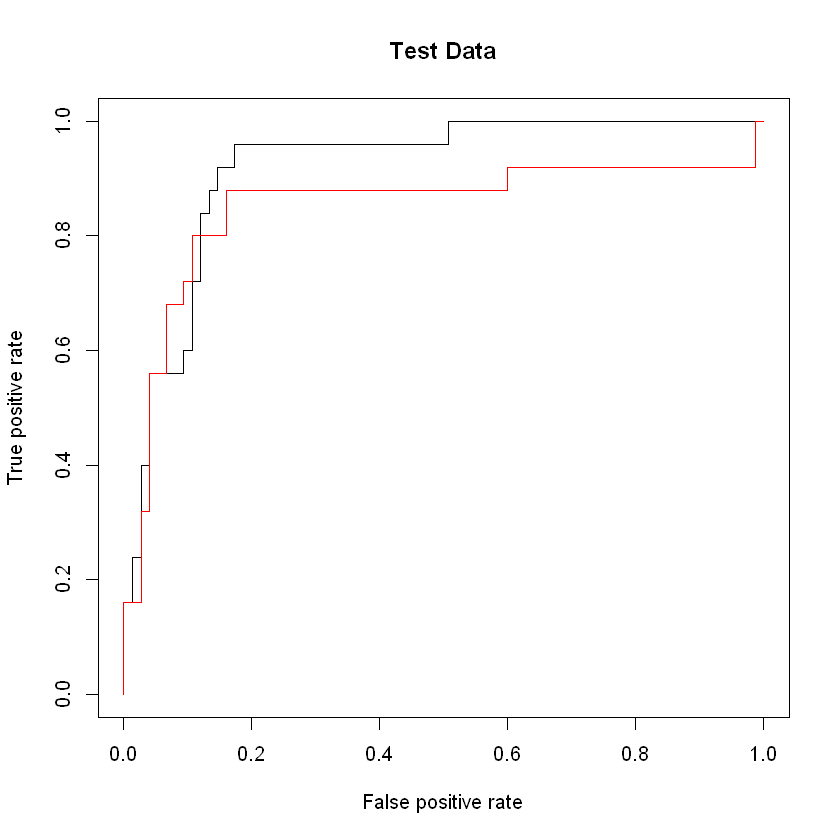

In [11]:
fitted =attributes (predict (svmfit.opt ,dat[- train ,], decision.values=T))$decision.values
rocplot (fitted ,dat[-train ,"y"], main="Test Data")
fitted=attributes (predict (svmfit.flex ,dat[- train ,], decision.values=T))$decision.values
rocplot (fitted ,dat[-train ,"y"],add=T,col="red")

# Lab 9.6.4

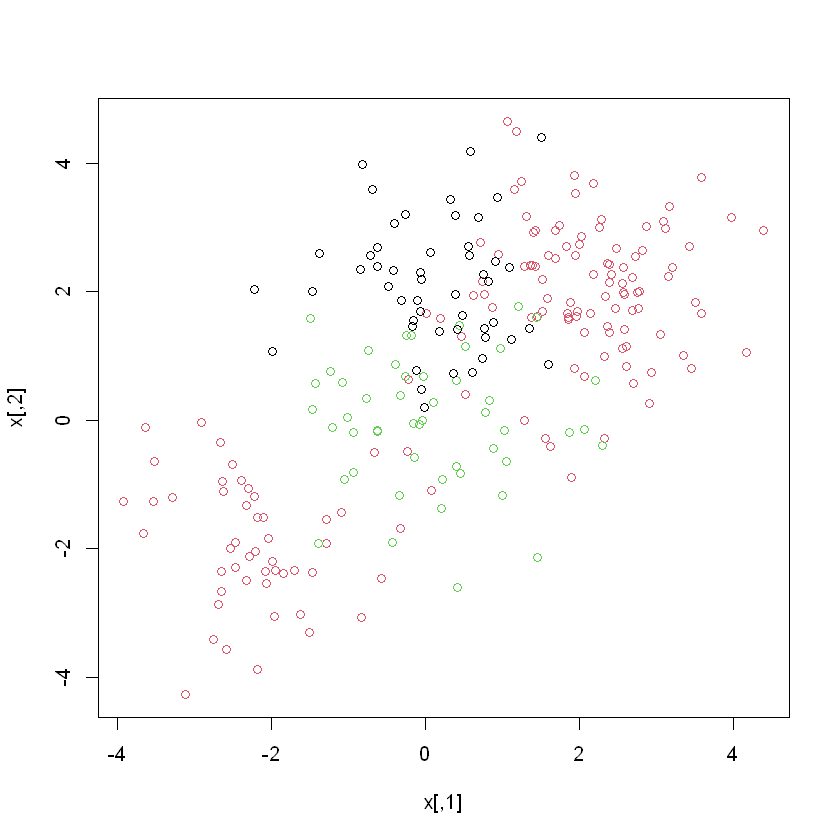

In [15]:
set.seed(1)
x=rbind(x, matrix(rnorm (50*2) , ncol=2))
y=c(y, rep(0,50))
x[y==0,2]= x[y==0 ,2]+2
dat=data.frame(x=x, y=as.factor(y))
par(mfrow=c(1,1))
plot(x,col=(y+1))

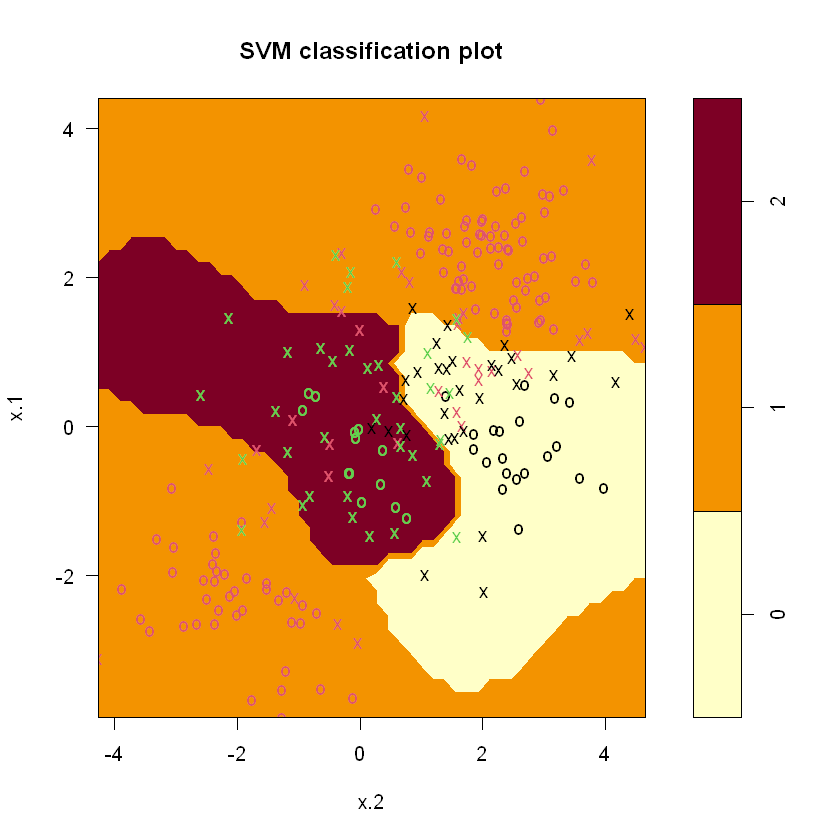

In [16]:
svmfit=svm(y~., data=dat , kernel ="radial", cost=10, gamma =1)
plot(svmfit , dat)